# Mini Project II - Rotten Tomatoes vs Box Office

Members:
- Anh Nguyen
- Kris Nguyen

## Introduction
Movies are often judged based on ideas and comments from critics and the audience themselves. However, whether those *scores* are fully able to determine whether the films will be a huge success or not is inconclusive.
<br><br>
By combining the datasets, we will analyze trends and relationships between *Rotten Tomatoes scores* and their *box office revenues* through different films. Through this project, we will pinpoint whether these two correlate to each other, in other words, do higher-rated films will be equivalent to higher box office.

### Data Preparation

In [27]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
# load datasets
ratings    = pd.read_csv("https://raw.githubusercontent.com/panhhng/ds256-mini/refs/heads/main/rotten_tomatoes.csv")
box_office = pd.read_csv("https://raw.githubusercontent.com/panhhng/ds256-mini/refs/heads/main/box_office.csv")

In [29]:
# extract and create a new column 'Year' for 'ratings'
ratings['releaseDateTheaters'] = pd.to_datetime(ratings['releaseDateTheaters'])
ratings['Year'] = ratings['releaseDateTheaters'].dt.year

In [30]:
# merge datasets through titles and release year
df = pd.merge(
    ratings,
    box_office,
    left_on=['title', 'Year'],
    right_on=['Release Group', 'Year']
)

### Data Cleaning

In [31]:
# drop rows with NA values
df = df.dropna(subset=['tomatoMeter', '$Worldwide'])

In [32]:
# keep only the columns that we'll be working with
df = df[['title', 'Year', 'tomatoMeter', '$Worldwide']]

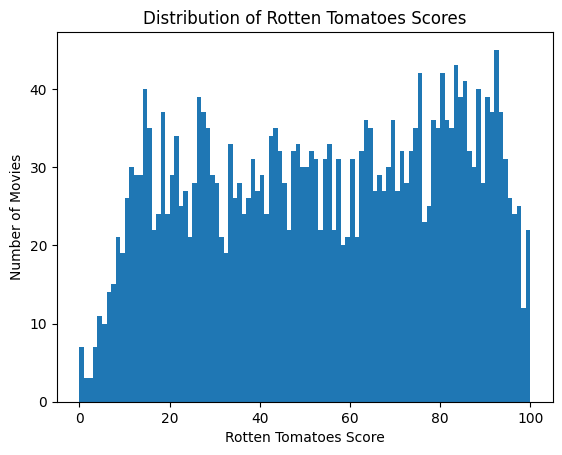

In [33]:
plt.hist(df['tomatoMeter'], bins=100)

plt.xlabel('Rotten Tomatoes Score')
plt.ylabel('Number of Movies')
plt.title('Distribution of Rotten Tomatoes Scores')

plt.show()

## Critics Don't Decide Box Office

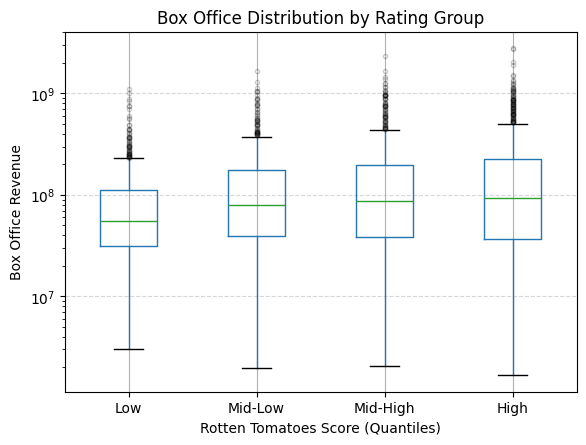

In [37]:
df['group'] = pd.qcut(
    df['tomatoMeter'],
    q=4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

df.boxplot(
    column='$Worldwide',
    by='group',
    flierprops=dict(marker='o', alpha=0.2, markersize=3)
)

plt.xlabel('Rotten Tomatoes Score (Quantiles)')
plt.ylabel('Box Office Revenue')
plt.title('Box Office Distribution by Rating Group')

plt.suptitle('')         
plt.yscale('log')       
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

From this chart, we can see how critics are not a factor here, at least for box office revenue. The distribution of the data points is remarkably stable across the divided quartiles. The median of the groups hovers around the $100 million mark, regardless of ratings from critics.

Blockbusters which earned above the $1 billion level appeared across all rating categories, denoting that poor reviews do not hinder the success of these films and not necessarily mean that these films will 'break'.

This suggests that factors that determine box office success vary widely, it may be franchise recognition, marketing strategies that decide as a whole. Ratings may help films to gain more rcognition in awards or prestige but in terms of revenues, they do not matter as audience are the ones who decide.